In [1104]:

import os
import pickle
import matplotlib.pyplot as plt
import glob
import ast
from datetime import datetime
from tabulate import tabulate
import numpy as np

#import tikzplotlib
from IPython.core.display import HTML

display(HTML("<style>.container {width:90% !important;}</style>"))
display(HTML("<style>pre { white-space: pre !important; }</style>"))
from operator import itemgetter

# path and env name
path = '/checkpoint/fcharton/dumped/'



quantum = True
# pre 23/6 beam_acc: reduced, no matter the nr of nodes, d3 = better or equal to full reduce
#xp_env=['zx_test']
#xp_env=['zx_test3']
#xp_env=['zx_test3_wu']
#xp_env=['zx_test3_heads']
#xp_env=['zx_scale_10_15']
#xp_env=['zx_scale_10_20']
#xp_env=['zx_scale_10_25']
# pre 23/6 beam_acc: better or equal that full reduce, d1 reduced d2 reduced, strictly better than src, d3 reduced, strictly better than tgt
#xp_env=['zx_3types']

#xp_env=['zx_qubits_3']
#xp_env=['zx_qubits_5']
#xp_env=['zx_qubits_10']
#xp_env=['zx_qubits_15']
#xp_env=['zx_qubits_20']
#xp_env=['zx_qubits_25']
#xp_env=['zx_qubits_30']

#xp_env=['zx_multiqbits']
#xp_env=['zx_multidepth']
#xp_env=['zx_verbose_encoding'] # KILLED : no impact

indicator = "valid_simplify"



xp_id_filter=[]
xp_id_selector=[]
#xp_id_selector=["433089"]
unwanted_args = ['dump_path']#, 'master_addr']#, 'reload_data']

has_beam=True


# global variables
var_args = set()
all_args = {}


# list experiments
xps = [(env, xp) for env in xp_env for xp in os.listdir(path+'/'+env) if (len(xp_id_selector)==0 or xp in xp_id_selector) and (len(xp_id_filter)==0 or not xp in xp_id_filter)]
names = [path + env + '/' + xp for (env, xp) in xps]
print(len(names),"experiments found")

# read all args
pickled_xp = 0
for name in names:
    pa = name+'/params.pkl'
    if not os.path.exists(pa):
        print("Unpickled experiment: ", name)
        continue
    pk = pickle.load(open(pa,'rb'))
    all_args.update(pk.__dict__)
    pickled_xp += 1
print(pickled_xp, "pickled experiments found")
print()

# find variable args
for name in names:
    pa = name+'/params.pkl'
    if not os.path.exists(pa):
        continue
    pk = pickle.load(open(pa,'rb'))
    for key,value in all_args.items():
        if key in pk.__dict__ and value == pk.__dict__[key]:
            continue
        if key not in unwanted_args:
            var_args.add(key)

print("common args")
for key in all_args:
    if key not in unwanted_args and key not in var_args:
        print(key,"=", all_args[key])
print()
            
print(len(var_args)," variables params out of", len(all_args))
print(var_args)



          

48 experiments found
48 pickled experiments found

common args
exp_name = pgcd_regular_grok
save_periodic = 0
fp16 = True
amp = 2
enc_emb_dim = 512
dec_emb_dim = 512
n_enc_layers = 4
n_dec_layers = 4
n_enc_heads = 8
n_dec_heads = 8
n_enc_hidden_layers = 1
n_dec_hidden_layers = 1
xav_init = False
gelu_activation = False
norm_attention = False
dropout = 0.0
attention_dropout = 0.0
share_inout_emb = True
sinusoidal_embeddings = False
enc_loop_idx = -1
dec_loop_idx = -1
enc_loops = 1
dec_loops = 1
enc_has_pos_emb = True
dec_has_pos_emb = True
gated = False
enc_gated = False
dec_gated = False
scalar_gate = False
biased_gates = False
gate_bias = 0
enc_act = False
dec_act = False
act_threshold = 0.01
act_ponder_coupling = 0.01
act_biased = False
act_bias = 0
max_len = 50
max_output_len = 25
batch_size = 256
eval_size = 100000
batch_size_eval = 1000
optimizer = adam,lr=0.00001
clip_grad_norm = 5.0
epoch_size = 300000
max_epoch = 100000
stopping_criterion = valid_arithmetic_acc,1500
validation_

In [1105]:

def vars_from_env_xp(env, xp):
    res = {}
    pa = path+env+'/'+xp+'/params.pkl'
    if not os.path.exists(pa):
        print("pickle", pa, "not found")
        return res
    pk = pickle.load(open(pa,'rb'))
    for key in var_args:
        if key in pk.__dict__: 
            res[key] = pk.__dict__[key]
        else:
            res[key] = None
    return res

def get_start_time(line):
    parsed_line = line.split(" ")
    dt = datetime.strptime(parsed_line[2]+' '+parsed_line[3],"%m/%d/%y %H:%M:%S")
    try:
        idx = parsed_line.index("epoch")
        curr_epoch = int(parsed_line[idx+1])
    except ValueError:
        curr_epoch = ""
    return dt, curr_epoch


def read_xp(env, xp, indics, max_epoch=None):
    res = {"env":env, "xp": xp, "stderr":False, "log":False, "error":False}
    stderr_file = os.path.join(os.path.expanduser("~"), 'workdir/'+env+'/*/'+xp+'.stderr')
    nb_stderr =len(glob.glob(stderr_file))
    if nb_stderr > 1:
        print("duplicate stderr", env, xp)
        return res
    for name in glob.glob(stderr_file):
        with open(name, 'rt') as f:
            res["stderr"]=True
            errlines = []
            cuda = False
            terminated = False
            forced = False
            for line in f:
                if line.find("RuntimeError:") >= 0:
                    errlines.append(line)
                if line.find("CUDA out of memory") >= 0:
                    cuda = True
                if line.find("Exited with exit code 1") >=0:
                    # print(stderr_file)
                    terminated = True
                
                if line.find("Force Terminated") >=0:
                    # print(stderr_file)
                    forced = True
            res["forced"] = forced
                
            res["terminated"] = terminated
            if len(errlines) > 0:    
                res["error"] = True
                res["runtime_errors"] = errlines
                res["oom"] = cuda 
                if not cuda:
                    print(stderr_file,"runtime error no oom")
               
    pa = path+env+'/'+xp+'/train.log'
#    print(pa)
    if not os.path.exists(pa):
        return res
    res["log"] = True
    with open(pa, 'rt') as f:
        series = []
        train_loss=[]
        for ind in indics:
            series.append([])
        best_val = -1.0
        best_xel = 999999999.0
        best_epoch = -1
        epoch = -1
        val = -1
        ended = False
        nanfound = False
        res["curr_epoch"]=-1
        res["train_time"]=0
        res["eval_time"]=0
        res["pred_nr"]=[]
        nb_sig10 = 0
        nb_sig15 = 0
        counter = 0
        counting = False
        for line in f:
            try:
                if counting:
                    counter += 1
                if line.find("Signal handler called with signal 10") >= 0:
                    nb_sig10 += 1
                if line.find("Signal handler called with signal 15") >= 0:
                    nb_sig15 += 1
                if line.find("Stopping criterion has been below its best value for more than") >=0:
                    ended = True
                elif line.find("============ Starting epoch") >=0:
                    dt, curr_epoch = get_start_time(line)
                    if curr_epoch == max_epoch: break
                    res["start_time"] = dt
                    if curr_epoch >0 and curr_epoch == res["curr_epoch"]+1:
                        res["eval_time"] += (dt - res["end_time"]).total_seconds()
                    res["curr_epoch"] = curr_epoch
                elif line.find("============ End of epoch") >=0:
                    dt, curr_epoch = get_start_time(line)
                    if curr_epoch != res["curr_epoch"]:
                        print("epoch mismatch", curr_epoch,"in", env,",", xp)
                    else:
                        res["end_time"] = dt
                        res["train_time"] += (dt-res["start_time"]).total_seconds()
                elif line.find("- model LR:") >=0:
                    loss = line.split(" ")[-5].strip()
                    train_loss.append(None if loss == 'nan' else float(loss)) 
                elif line.find("- LR:") >=0:
                    loss = line.split(" ")[-4].strip()
                    if loss == "predictions.":
                        print(line)
                    else:    
                        train_loss.append(None if loss == 'nan' else float(loss)) 
                elif line.find('- test predicted pairs') >=0:
                    counter = 0
                    counting = True
                else:                 
                    pos = line.find('__log__:')
                    if pos >=0:
                        counting = False
                        res['pred_nr'].append(counter/100.0)
                        if line[pos+8:].find(': NaN,') >= 0:
                            nanfound = True
                            line = line.replace(': NaN,',': -1.0,')
                        dic = ast.literal_eval(line[pos+8:])
                        epoch = dic["epoch"]
                        if not indicator+"_"+indics[0] in dic: 
                            continue
                        if not indicator+"_"+indics[1] in dic: 
                            continue
                        val = dic[indicator+"_"+indics[0]]
                        xel = dic[indicator+"_"+indics[1]]
                        if xel < best_xel:
                            best_xel= xel
                        if val > best_val:
                            best_val = val
                            best_epoch = epoch 
                            res["best_dic"] = dic
                        for i, indic in enumerate(indics):
                            if indicator+"_"+indic in dic:
                                series[i].append(dic[indicator+"_"+indic])
                                
            except e as Exception:
                print(e, "exception in", env, xp)
                continue  
            except:
                print(line)
                continue
        res["nans"] = nanfound
        res["ended"] = (ended or (nb_sig15 > nb_sig10))
        res["last_epoch"] = epoch
        res["last_acc"] = "{:.2f}".format(val)
        res["best_epoch"] = best_epoch
        res["best_acc"] = float("{:.2f}".format(best_val))
        res["best_xeloss"] = "{:.2f}".format(best_xel)
        res["train_loss"]=train_loss
        res["avg_d"] = np.median(res['pred_nr'])
        res["last_d"] = res['pred_nr'][-1] if len(res['pred_nr']) > 0 else -1
        if epoch >=0:
            res["train_time"] /= (epoch+1)
            res["eval_time"] /= (epoch+1)
        res["train_time"] = int(res["train_time"]+0.5) 
        res["eval_time"] = int(res["eval_time"]+0.5) 
            
        for i,indic in enumerate(indics):
            res["last_"+indic] = "{:.2f}".format(series[i][-1]) if len(series[i])>0 else '0'
            res["best_"+indic] = "{:.2f}".format(max(series[i])) if len(series[i])>0 else '0'
            res[indic] = series[i]
            if len(series[i])!= epoch + 1:
                print("mismatch in nr of epochs",env, xp, epoch+1, len(series[i]), indic)      
    return res


    
# read experiments
data = []
indics = ["beam_acc" if has_beam is True else "acc","xe_loss"]
if quantum:
    indics.extend(["correct", "perfect", "beam_acc_d1", "beam_acc_d2", "beam_acc_d3"])
for (env, xp) in xps:
    res = read_xp(env, xp, indics, None)
    res.update(vars_from_env_xp(env, xp))
    data.append(res)


print(len(data), "experiments read")
print(len([d for d in data if d["stderr"] is False]),"stderr not found")
print(len([d for d in data if d["error"] is True]),"runtime errors")
print(len([d for d in data if "oom" in d and d["oom"] is True]),"oom errors")
print(len([d for d in data if "terminated" in d and d["terminated"] is True]),"exit code 1")
print(len([d for d in data if "forced" in d and d["forced"] is True]),"Force Terminated")
print(len([d for d in data if "last_epoch" in d and d["last_epoch"] >= 0]),"started XP")
print(len([d for d in data if "ended" in d and d["ended"] is True]),"ended XP")
print(len([d for d in data if "best_acc" in d and float(d["best_acc"]) > 0.0]),"began predicting")





48 experiments read
0 stderr not found
0 runtime errors
0 oom errors
0 exit code 1
0 Force Terminated
48 started XP
47 ended XP
48 began predicting


CUDA out of memory (0)
+------+--------+---------------+--------------------+-------------+
| base | exp_id | env_base_seed | train_inverse_dist | master_addr |
+------+--------+---------------+--------------------+-------------+
+------+--------+---------------+--------------------+-------------+
Forced terminations (0)
+------+--------+---------------+--------------------+-------------+
| base | exp_id | env_base_seed | train_inverse_dist | master_addr |
+------+--------+---------------+--------------------+-------------+
+------+--------+---------------+--------------------+-------------+
Not started (0)
+------+--------+---------------+--------------------+-------------+
| base | exp_id | env_base_seed | train_inverse_dist | master_addr |
+------+--------+---------------+--------------------+-------------+
+------+--------+---------------+--------------------+-------------+
Running experiments (3)

+----------+------------+-------------+-------+------------+----------+-------------

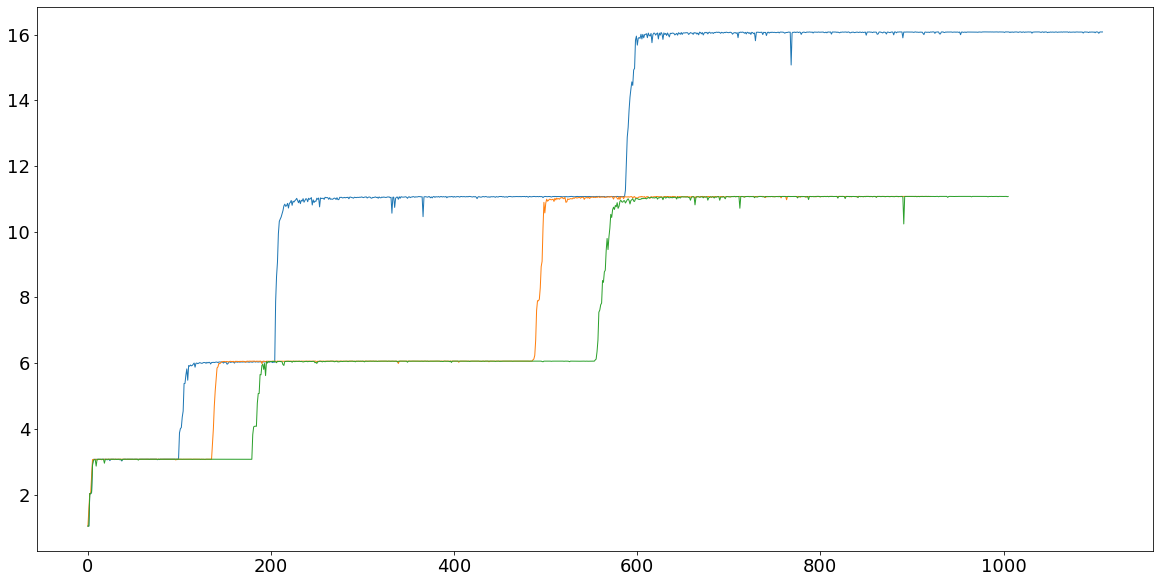

pred_nr


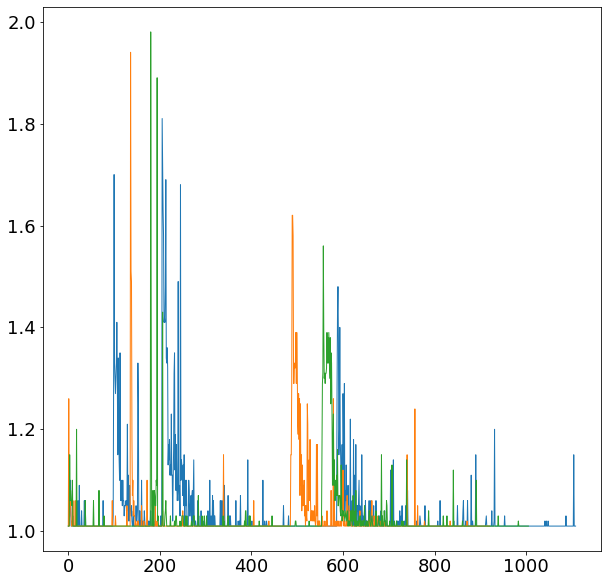

xe_loss


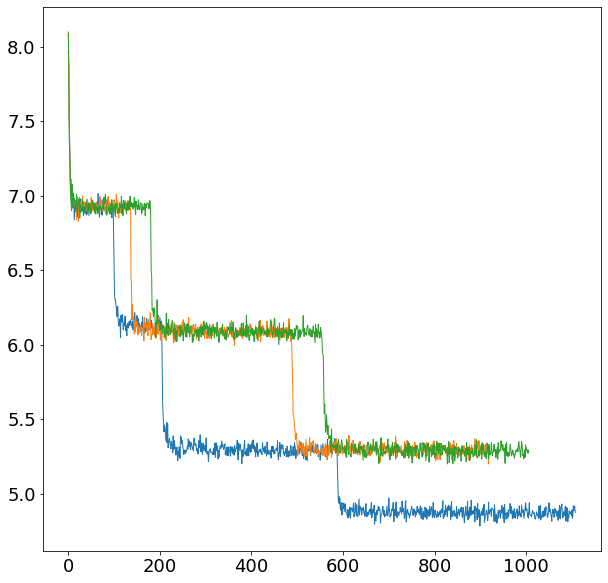

train_loss


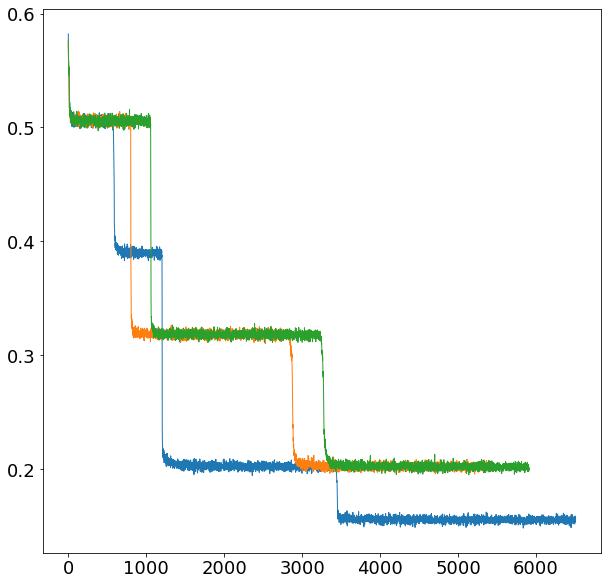

+----------+-------------+------------+-------------+-------+------------+----------+--------------+-------+-------+------------+-----------+--------+-------+------+----------+---------------+--------------------+---------------+
| best_acc | first epoch | best_epoch | best_xeloss | ended | last_epoch | last_acc | last_xe_loss | nans  | error | train_time | eval_time | last_d | avg_d | base |  exp_id  | env_base_seed | train_inverse_dist |  master_addr  |
+----------+-------------+------------+-------------+-------+------------+----------+--------------+-------+-------+------------+-----------+--------+-------+------+----------+---------------+--------------------+---------------+
|  16.08   |    1000     |    881     |    4.78     | True  |    1108    |  16.08   |     4.88     | False | False |    172     |    359    |  1.01  | 1.01  | 2023 | 12989406 |      -2       |       False        | learnfair2100 |
|  11.08   |    1000     |    705     |    5.20     | True  |    920     |  11.0

In [1110]:
import numpy as np


def compose(f,g):
    return lambda x : f(g(x))

def print_table(data, args, sort=False):
    res = []
    for d in data:
        line = [d[v] if v in d else None for v in args]
        res.append(line)
    if sort:
        res = sorted(res, key=compose(float,itemgetter(0)), reverse=True)
    print(tabulate(res,headers=args,tablefmt="pretty"))


    
def speed_table(data, args, indic, sort=False, percent=95):
    res = []
    for d in data:
        
        if indic in d:
            line = [d[v] if v in d else None for v in args]
            val= 1000
            for i,v in enumerate(d[indic]):
                if v >= percent and i < val:
                    val = i
                    
            line.insert(1,val)
            res.append(line)
    e= args.copy()
    e.insert(1,'first epoch')
    if sort:
        res = sorted(res, key=compose(float,itemgetter(1)), reverse=False)
    print(tabulate(res,headers=e,tablefmt="pretty"))

    
def training_curve(data, indic, beg=0, end=-1, maxval=None, minval=None):
    print(indic)
    for d in data:
        if indic in d:
            if end == -1:
                plt.plot(d[indic][beg:],linewidth=1)
            else:
                plt.plot(d[indic][beg:end],linewidth=1)
    plt.ylim(minval,maxval)
    plt.rcParams['figure.figsize'] = [10,10]
    plt.show()


def filter_xp(xp, filt):
    for f in filt:
        if not f in xp:
            return False
        if not xp[f] in filt[f]:
            return False
    return True

def xp_stats(data, splits, best_arg, best_value):
    res_dic = {}
    nb = 0
    for d in data:
        if d[best_arg] < best_value: continue
        nb += 1
        for s in splits:
            if not s in d: continue
            lib=s+':'+str(d[s])
            if lib in res_dic:
                res_dic[lib] += 1
            else:
                res_dic[lib]=1
                
    print()
    print(f"{nb} experiments with accuracy over {best_value}")
    for elem in sorted(res_dic):
        print(elem,' : ',res_dic[elem])
    print()

xp_filter ={} 

#xp_filter.update({"mixture":[0.05]})

#xp_filter.update({"optimizer":["adam_inverse_sqrt,warmup_updates=10000,warmup_init_lr=0.0000001,lr=0.0001"]})
#xp_filter.update({"secret":["724"]})
#xp_filter.update({"batch_size":[64]})
#xp_filter.update({"optimizer":["adam_warmup,warmup_updates=3000,lr=0.00001"]}) 



#xp_filter.update({"reload_data":[#"boots,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_10.prefix.train,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_10.prefix.valid,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_10.prefix.valid",
                                 #"boots,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_25.prefix.train,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_25.prefix.valid,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_25.prefix.valid",
                                 #"boots,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_50.prefix.train,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_50.prefix.valid,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_50.prefix.valid",
#                                 "boots,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_100.prefix.train,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_100.prefix.valid,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_100.prefix.valid",
#                                ]})
#xp_filter.update({"n_enc_layers":[8,12]})
#xp_filter.update({"n_dec_layers":[4]})
#xp_filter.update({"eval_size":[10000],"sign_last":[False]})
#xp_filter.update({"reload_data":["boots,/private/home/fcharton/Amplitudes/ML/loop5_reg_nz_10.prefix.train,/private/home/fcharton/Amplitudes/ML/loop5_reg_nz_10.prefix.valid,/private/home/fcharton/Amplitudes/ML/loop5_reg_nz_10.prefix.valid",
#"boots,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_10.prefix.train,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_10.prefix.valid,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_10.prefix.valid"]})
#xp_filter.update({"reload_data":[#"boots,/private/home/fcharton/Amplitudes/ML/loop5_reg_nz_100.prefix.train,/private/home/fcharton/Amplitudes/ML/loop5_reg_nz_100.prefix.valid,/private/home/fcharton/Amplitudes/ML/loop5_reg_nz_100.prefix.valid",
#"boots,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_100.prefix.train,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_100.prefix.valid,/private/home/fcharton/Amplitudes/ML/loop6_reg_nz_100.prefix.valid"]})
#xp_filter.update({"optimizer":["adam,lr=0.0001"]}) 
#xp_filter.update({"env_base_seed":[-3]}) 

#xp_filter.update({"enc_loop_idx":[-1],"dec_loop_idx":[0]})
#19, 37, 67, 107, 251, 367, 967, 1471, 3217, 6421, 11197, 20663,
#42899, 130769, 147647, 397921, 842279, 1489513, 3578353, 6139999
#397921 
#xp_filter.update({"reload_size": [1000000]})
#xp_filter.update({"train_inverse_dist":[True]})
#xp_filter= {"optimizer":["adam_cosine,warmup_updates=50000,lr=0.001,init_period=1000000,lr_shrink=0.1","adam_cosine,warmup_updates=50000,lr=0.0005,init_period=1000000,lr_shrink=0.1"]}
#xp_filter.update({"ended":[False]}) # , "min_dimension":[8,9,10]}


#xp_filter.update({"optimizer":["adam_cosine,warmup_updates=10000,lr=0.00005,min_lr=0.000005,init_period=4000000,lr_shrink=0.1,lr_shrink_min=0.1"]})
# regular
#xp_filter.update({"exp_id":["11885653","11885652","11885642"]})
#mix
#xp_filter.update({"exp_id":["12392666","12392619","12392625","12392628"]})


fdata = [d for d in data if filter_xp(d, xp_filter) is True]

oomtab = [d for d in fdata if d["error"] is True]
print(f"CUDA out of memory ({len(oomtab)})")
print_table(oomtab, var_args)

forcetab = [d for d in fdata if 'forced' in d and d["forced"] is True]
print(f"Forced terminations ({len(forcetab)})")
print_table(forcetab, var_args)

unstartedtab = [d for d in fdata if "last_epoch" in d and d["last_epoch"] < 0] 
print(f"Not started ({len(unstartedtab)})")
print_table(unstartedtab, var_args)

crypto = False
runargs = ["best_acc", "best_epoch","best_xeloss",  "ended", "last_epoch", "last_acc", "last_xe_loss","nans", "error", "train_time", "eval_time"]
if quantum:
    runargs.extend(["best_correct","last_correct", "best_beam_acc_d1" , "best_beam_acc_d2" ,"best_beam_acc_d3", "best_perfect"])
for v in var_args:
    runargs.append(v)
runningtab = [d for d in fdata if "last_epoch" in d and d["last_epoch"] >= 0] 
print(f"Running experiments ({len(runningtab)})")

#splits = ['n_enc_layers','dec_emb_dim','reload_size'] 
#xp_stats(fdata, splits, 'best_acc',90.0)
print()

print_table(runningtab, runargs, sort=True)

#plt.rcParams['figure.figsize'] = [10, 10]
#plt.rc('xtick', labelsize=14) 
#plt.rc('ytick', labelsize=14) 

training_curve(fdata, "beam_acc" if has_beam is True else "acc", 0)

if quantum:
    training_curve(fdata, "perfect")
    training_curve(fdata, "correct")
    training_curve(fdata, "beam_acc_d1")
    training_curve(fdata, "beam_acc_d2")
    training_curve(fdata, "beam_acc_d3")

    
training_curve(fdata, "xe_loss", 0) #, None, 0.9* np.min([x for d in fdata for x in d["xe_loss"] if x >0.0]))
#training_curve(fdata, "acc")
training_curve(fdata, "train_loss", 1, -1)
speed_table(runningtab, runargs, "beam_acc" if has_beam else "acc", sort=True,percent=95)
speed_table(runningtab, runargs, "beam_acc" if has_beam else "acc", sort=True,percent=98)

                   
                   

4135
1109 4135
921 4135
1006 4135


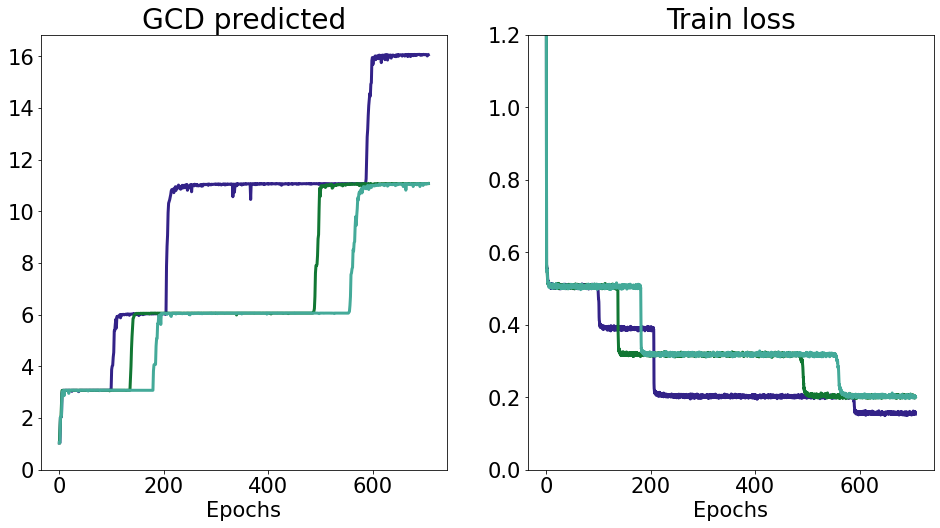

In [1121]:
colors = ['#332288', '#117733', '#44AA99', '#88CCEE', '#DDCC77', '#CC6677', '#AA4499', '#882255', 'black', 'grey']
fig, ax = plt.subplots(1,2)


def c_training_curve(data, indic, indic2, beg=0, end=-1, maxval=None, maxval2=None):
    #print([d["base"] for d in data])
    data = sorted(data, key=compose(float,itemgetter("best_acc")), reverse=True)
    end2=int(end*5.85)
    print( end2-beg) #d[indic2]))
    #print([d["base"] for d in data])
    c=0
    for d in data:
        print(len(d[indic]),len(d[indic2][beg:end2]))
        if indic in d:
            if end == -1:
                ax[0].plot(d[indic][beg:],linewidth=3,label=d["base"],color=colors[c])
            else:
                ax[0].plot(d[indic][beg:end],linewidth=3,label=d["base"],color=colors[c])
        if indic2 in d:
            if end == -1:
                ax[1].plot(d[indic2][beg:],linewidth=3,label=d["base"],color=colors[c])
            else:
                ax[1].plot(np.arange(0,(end2-beg)/5.85,1/5.85),d[indic2][beg:end2],linewidth=3,label=d["base"],color=colors[c])
        c = c+1
    ax[0].set_title("GCD predicted",fontsize=28)
    ax[1].set_title("Train loss",fontsize=28)
    ax[0].set_ylim(0,maxval)
    ax[1].set_ylim(0,maxval2)
    #ax[1].legend(title="base",title_fontsize=18,fontsize=18)
    axs[0].tick_params(axis='both', which='major', labelsize=21)
    axs[1].tick_params(axis='both', which='major', labelsize=21)
    ax[1].set_xlabel("Epochs",fontsize=21)
    ax[0].set_xlabel("Epochs",fontsize=21)


    
    
    #plt.rcParams['figure.figsize'] = [8,16]


c_training_curve(fdata, "acc","train_loss",0,707, None,1.2)
#fig.font.
plt.rcParams['figure.figsize'] = [16, 8]
#plt.rcParams.update({
#    "pgf.texsystem": "pdflatex",
#    "font.family" : "serif",
#    "font.serif" : ["Roman","Palatino"],
#    'text.usetex': True,
#    'pgf.rcfonts': False,
#})

#plt.rc('xtick', labelsize=21) 
#plt.rc('ytick', labelsize=21) 
plt.savefig("LearningCurvesGrok.pdf",bbox_inches="tight")
plt.savefig("LearningCurveGrok.eps",bbox_inches="tight",dpi=1200)
plt.show()




The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


1755


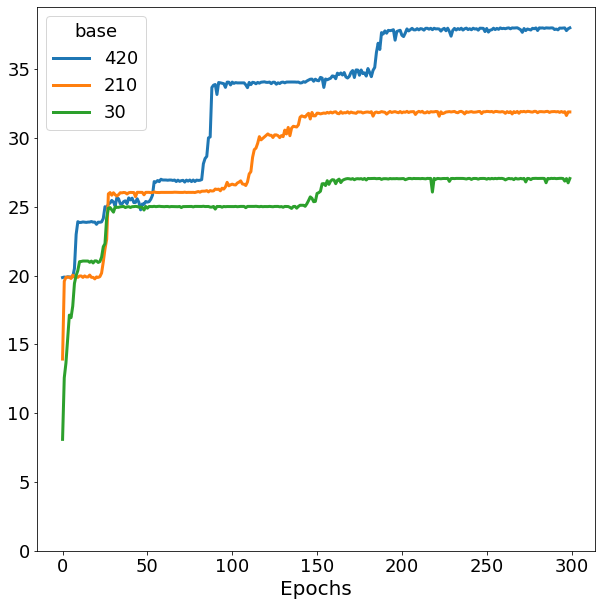

In [995]:
colors = ['#332288', '#117733', '#44AA99', '#88CCEE', '#DDCC77', '#CC6677', '#AA4499', '#882255', 'black', 'grey']
fig, ax = plt.subplots(1,1)


def c_training_curve(data, indic, indic2, beg=0, end=-1, maxval=None, maxval2=None):
    #print([d["base"] for d in data])
    data = sorted(data, key=compose(float,itemgetter("best_acc")), reverse=True)
    end2=int(end*5.85)
    print( end2-beg)#, len(d[indic2]))
    #print([d["base"] for d in data])
    for d in data:
        if indic in d:
            if end == -1:
                ax.plot(d[indic][beg:],linewidth=3,label=d["base"])
            else:
                ax.plot(d[indic][beg:end],linewidth=3,label=d["base"])
    #ax.set_title("GCD predicted",fontsize=20)
    ax.set_ylim(0,maxval)
    ax.legend(title="base",title_fontsize=18,fontsize=18)
    ax.set_xlabel("Epochs",fontsize=20)

    
    #plt.rcParams['figure.figsize'] = [8,16]


c_training_curve(fdata, "acc","train_loss",0,300, None, 0.8)
#fig.font.
plt.rcParams['figure.figsize'] = [10, 10]
plt.rcParams.update({
#    "pgf.texsystem": "pdflatex",
    "font.family" : "serif",
    "font.serif" : ["Roman","Palatino"],
 #   'text.usetex': True,
#    'pgf.rcfonts': False,
})

plt.rc('xtick', labelsize=18) 
plt.rc('ytick', labelsize=18) 
#plt.savefig("UniGCD.pdf",bbox_inches="tight")
plt.savefig("LearningCurvesMix.eps",bbox_inches="tight",dpi=1200)
plt.show()



findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


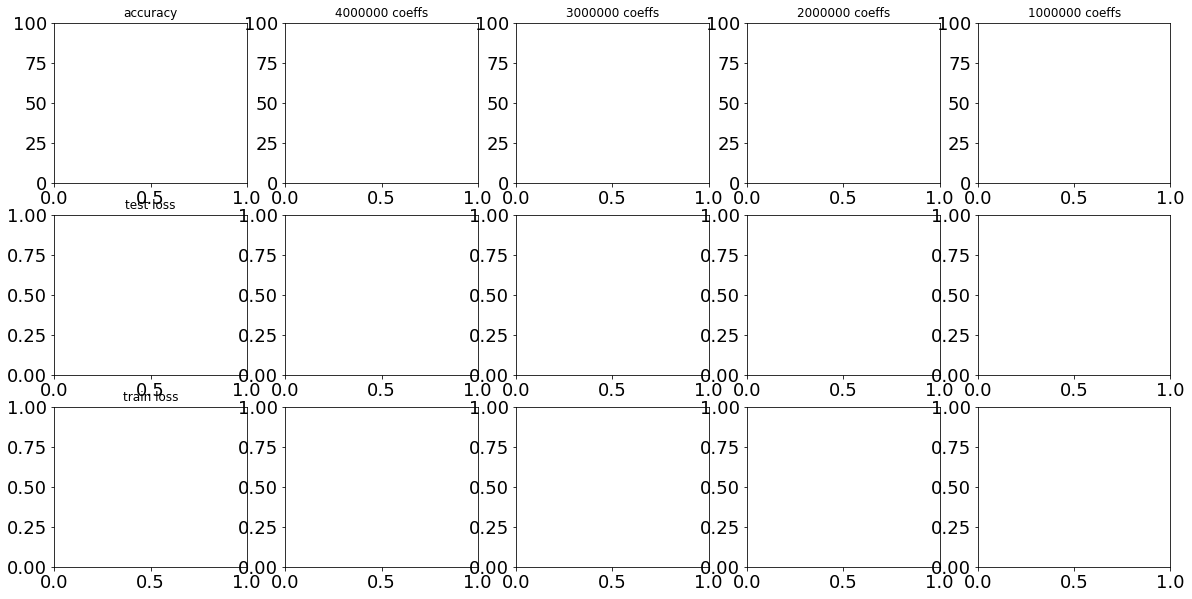

In [37]:
# group tables : 

# vertical indic:
vertical_indicator= "reload_size"
vert_values = [-1, 4000000,3000000,2000000,1000000]
fdata=[]
for v in vert_values: 
    fdata.append([d for d in data if filter_xp(d, {vertical_indicator: [v]}) is True])

horz_indics = ["beam_acc", "xe_loss","train_loss"]
titles = ["accuracy","test loss", "train loss"]

fig, axs = plt.subplots(len(horz_indics),len(vert_values))
for i,d in enumerate(fdata):
    for j,indic in enumerate(horz_indics):
        for s in d:
            axs[j][i].plot(s[indic][:])
        axs[j,0].set_title(titles[j])
    axs[0,i].set_ylim([0,100]) 
    axs[2,i].set_ylim([0,1]) 
    if i!=0:
        axs[0,i].set_title(str(vert_values[i])+" coeffs")        
            

plt.rcParams['figure.figsize'] = [25, 15]

plt.show()




In [547]:
prefix = "test_arithmetic_acc_"
args =["best_acc","exp_id","base"]

def tab_learned_gcd(args,min_rate,max_rate):
    # comppute values
    res=[]
    for d in fdata:
        if "best_dic" in d:
            line = [d["best_acc"], d["exp_id"], d["base"]]
            line.append([k[len(prefix):] for k,v in d["best_dic"].items() if v >= min_rate and v<= max_rate and k.startswith(prefix) and k[len(prefix)] != 'd'])
            res.append(line)
    # insert 
    res = sorted(res, key=compose(float,itemgetter(0)), reverse=True)
    args.append("result")
    print(tabulate(res,headers=args,tablefmt="pretty",stralign="left"))

success_rate = 75
max_success_rate = 95

#args =["best_acc","exp_id","base"]
tab_learned_gcd(args,95,100)
tab_learned_gcd(args,75,95)
tab_learned_gcd(args,25,75)


+----------+----------+------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| best_acc | exp_id   | base | result                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
+----------+----------+------+------------------

(2,)
/checkpoint/fcharton/dumped/pgcd_regular_test/11738035/train.log
106 106
/checkpoint/fcharton/dumped/pgcd_regular_test/11738056/train.log
106 106
/checkpoint/fcharton/dumped/pgcd_regular_test/11737969/train.log
106 106
/checkpoint/fcharton/dumped/pgcd_regular_test/11737954/train.log
106 106
/checkpoint/fcharton/dumped/pgcd_regular_test/11738038/train.log
106 106
/checkpoint/fcharton/dumped/pgcd_regular_test/11738052/train.log
106 106
/checkpoint/fcharton/dumped/pgcd_regular_test/11738037/train.log
106 106


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


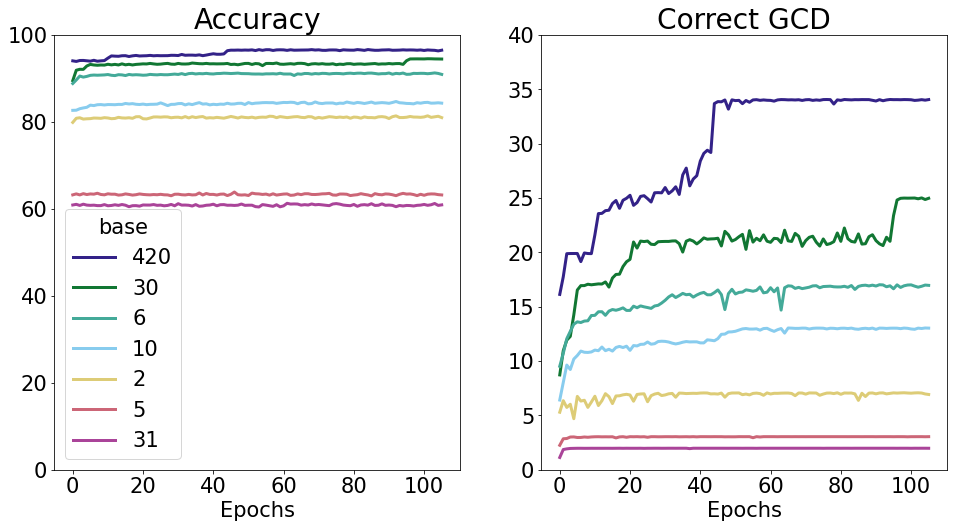

In [1103]:
import numpy as np
import os
import matplotlib.pyplot as plt
from IPython.core.display import HTML

display(HTML("<style>.container {width:90% !important;}</style>"))
display(HTML("<style>pre { white-space: pre !important; }</style>"))



#titles = ['Transposition\n5-15 rectangular matrices','Addition\n10x10 matrices', 'Matrix vector multiplication\n5x5 matrices', 'Eigenvalues\n5x5 matrices', 'Eigenvalues\n5-15 matrices', 'Eigenvalues\n10x10 matrices', 'Singular Values\n4x4 matrices', 'Eigenvectors\n6x6 matrices', 'Matrix Inversion\n5x5 matrices']
#max_epoch=[None,None,25,60,None,None,300,200,400]
  
path = [
['/checkpoint/fcharton/dumped/pgcd_regular_test/11738035',
 '/checkpoint/fcharton/dumped/pgcd_regular_test/11738056',
 '/checkpoint/fcharton/dumped/pgcd_regular_test/11737969',
 '/checkpoint/fcharton/dumped/pgcd_regular_test/11737954',
 '/checkpoint/fcharton/dumped/pgcd_regular_test/11738038',
 '/checkpoint/fcharton/dumped/pgcd_regular_test/11738052',
 '/checkpoint/fcharton/dumped/pgcd_regular_test/11738037']
 
#['/checkpoint/fcharton/dumped/pgcd_regular_uni/12347385']
#'/checkpoint/fcharton/dumped/pgcd_regular_uni/12347374',
#'/checkpoint/fcharton/dumped/pgcd_regular_uni/12347373']
]

#['/checkpoint/fcharton/dumped/pgcd_regular_uni/12347373',
#'/checkpoint/fcharton/dumped/pgcd_regular_uni/12347377',
#'/checkpoint/fcharton/dumped/pgcd_regular_uni/12347401']
#]

#['/checkpoint/fcharton/dumped/pgcd_regular_uni/12347373',


libs=[['420','30','6','10','2','5','31'],
     
     ]

probs=["","Addition (10x10)","Eigenvalues","Eigenvectors",'Inversion']
max_len=[105]
top_xe=[4]
 
colors = ['#332288', '#117733', '#44AA99', '#88CCEE', '#DDCC77', '#CC6677', '#AA4499', '#882255', 'black', 'grey']
    
    
#fig, axs = plt.subplots(2, 2)
#axs[0, 0].plot(x, y)
#axs[0, 0].set_title('Axis [0, 0]')
#axs[0, 1].plot(x, y, 'tab:orange')
#axs[0, 1].set_title('Axis [0, 1]')
#axs[1, 0].plot(x, -y, 'tab:green')
##axs[1, 0].set_title('Axis [1, 0]')
#axs[1, 1].plot(x, -y, 'tab:red')
#axs[1, 1].set_title('Axis [1, 1]')

#for ax in axs.flat:
#    ax.set(xlabel='x-label', ylabel='y-label')

# Hide x labels and tick labels for top plots and y ticks for right plots.
#for ax in axs.flat:
#    ax.label_outer()


fig, axs = plt.subplots(1,2)
print(np.shape(axs))

i1 = 'valid_arithmetic_acc'
#i2 ='valid_arithmetic_xe_loss'
i3 = 'test_arithmetic_acc' 
i4 = 'epoch'

for i in range(1):
    for j in range(7):
        pa = path[i][j]+'/train.log'
        print(pa)
        with open(pa, 'rt') as f:
                series1 = []
  #              series2 = []
                series3 = []
                series4 = []
                for line in f:
                    pos = line.find('__log__:')
                    try:
                        if pos >=0:
                            dic = ast.literal_eval(line[pos+8:])
                            series1.append(dic[i1])
 #                           series2.append(dic[i2])
                            series3.append(dic[i3])
                            series4.append(dic[i4])
                            if not max_len[i] is None and dic[i4] == max_len[i]: 
                               break
                    except:
                        continue
                print(len(series1), len(series4))
                axs[0].plot(series4,series1,label=libs[i][j],linewidth=3,color=colors[j])
   #             axs[2].plot(series4,series2, label=libs[i][j],linewidth=2)
                axs[1].plot(series4,series3, label=libs[i][j],linewidth=3, color=colors[j])
#            if not max_epoch[3*i + j] is None:
#                axs[i,j].set_xlim([-2,max_epoch[3*i + j]+2])
#            if i==1 and j==0:
#                axs[i,j].set_xlim([-2,102])
#            if i==1 and j==1:
#                axs[i,j].set_xlim([-2,62])
                
#            top_title = f'{titles[3*i+j]}'
#            axs[i,j].set_title(top_title,fontsize=20)
    axs[0].set_ylim([0,100])   
    axs[1].set_ylim([0,40])
 #   axs[2].set_ylim([0,top_xe[i]])
    axs[0].set_title(probs[i]+"Accuracy",fontsize=28)
    axs[1].set_title(probs[i]+"Correct GCD",fontsize=28)
  #  axs[2].set_title(probs[i]+"Loss",fontsize=18)
    axs[0].legend(title="base",title_fontsize=21,fontsize=21)
    #axs[0].legend.set_title("log q",fontsize=14)
    axs[0].tick_params(axis='both', which='major', labelsize=21)
    axs[1].tick_params(axis='both', which='major', labelsize=21)
   # axs[2].tick_params(axis='both', which='major', labelsize=32)
    axs[0].set_xlabel("Epochs",fontsize=21)
    axs[1].set_xlabel("Epochs",fontsize=21)
    #axs[2].set_xlabel("Epochs",fontsize=32)

    
#for ax in axs.flat:
#    ax.label_outer()

#plt.title("Accuracy vs epoch")

#plt.xlabel("Epochs",fontsize=14)

#plt.ylabel("Accuracy")
#plt.grid(True)

#axs[1].legend(fontsize=14)
#axs[2].legend(fontsize=14)

plt.rcParams['figure.figsize'] = [16, 8]

plt.savefig("LearningCurvesGCDBase.eps",bbox_inches="tight",dpi=1200)
plt.show()


In [577]:
import numpy as np
import os
import matplotlib.pyplot as plt
from IPython.core.display import HTML

display(HTML("<style>.container {width:90% !important;}</style>"))
display(HTML("<style>pre { white-space: pre !important; }</style>"))


path = ['/checkpoint/fcharton/dumped/pgcd_regular_uni/12347373',
'/checkpoint/fcharton/dumped/pgcd_regular_uni/12347377',
'/checkpoint/fcharton/dumped/pgcd_regular_uni/12347401']





max_len=[800]
top_xe=[4]
 

i1 = 'valid_arithmetic_acc'
i2 ='valid_arithmetic_xe_loss'
i3 = 'test_arithmetic_acc' 
i4 = 'epoch'

minval = 95

series = []
for i in range(101):
    series.append([])
#print(series)

for j in range(1):
    pa = path[j]+'/train.log'
    print(pa)
    with open(pa, 'rt') as f:
            for line in f:
                pos = line.find('__log__:')
                try:
                    if pos >=0:
                        dic = ast.literal_eval(line[pos+8:])
                        epoch = dic['epoch']
                        for i in range (1,101):
                            if dic['test_arithmetic_acc_'+str(i)] >= minval:
                                series[i].append(1)
                            else:
                                series[i].append(0)
                except:
                    continue

maxepoc=len(series[1])
pred = []
for i in range(20,101):
    for j in range(maxepoc):
        prop = sum(series[i][j:]) / (maxepoc-j)
        if prop >= 0.9:
            pred.append((j, i))
            break
for  u in sorted(pred):
    print(u)    
    #print("".join(series[i]))
#for ax in axs.flat:
#    ax.label_outer()

#plt.title("Accuracy vs epoch")

#plt.xlabel("Epochs",fontsize=14)

#plt.ylabel("Accuracy")
#plt.grid(True)

#axs[1].legend(fontsize=14)
#axs[2].legend(fontsize=14)

#plt.rcParams['figure.figsize'] = [15, 5]

#plt.savefig("LearningCurves10.eps",bbox_inches="tight",dpi=1200)
#plt.show()


/checkpoint/fcharton/dumped/pgcd_regular_uni/12347373/train.log
(0, 40)
(0, 50)
(0, 80)
(0, 100)
(200, 52)
(205, 65)
(237, 94)
(259, 47)
(268, 60)
(277, 56)
(279, 20)
(279, 35)
(279, 70)
(280, 91)
(285, 25)
(286, 48)
(287, 75)
(303, 84)
(304, 28)
(305, 78)
(306, 39)
(307, 26)
(307, 42)
(307, 96)
(319, 98)
(397, 90)
(425, 99)
(426, 66)
(430, 88)
(439, 72)
(440, 36)
(440, 63)
(443, 44)
(446, 45)
(451, 30)
(453, 24)
(453, 77)
(457, 21)
(470, 49)
(470, 55)
(476, 92)
(493, 33)
(501, 93)
(523, 85)
(526, 22)
(551, 95)
(565, 87)
(569, 86)
(576, 76)
(594, 68)
(596, 82)
(618, 64)
(618, 69)
(626, 46)
(649, 32)
(658, 57)
(677, 54)
(688, 62)
(717, 51)
(719, 81)
(728, 58)
(735, 97)
(740, 34)
(740, 74)
(740, 79)


In [633]:
import numpy as np
import os
import matplotlib.pyplot as plt
from IPython.core.display import HTML

display(HTML("<style>.container {width:90% !important;}</style>"))
display(HTML("<style>pre { white-space: pre !important; }</style>"))


path = '/checkpoint/fcharton/dumped/pgcd_regular_uni/12347385',
pa = path[j]+'/train.log'

epoch=400

vals = [(0,0.)]*101
with open(pa, 'rt') as f:
        for line in f:
            if line.find("Starting epoch "+str(epoch)) >= 0:
                break
        for line in f:
            if line.find("test predicted pairs") >=0: 
                break
        for line in f:
            if line.find("__log__") >=0:
                break
            preds = line.split(" ")[-3][:-1]
            
            v1, v2 = preds.split("-")
            prob = float(line.split(" ")[-1][1:-3])
            if prob > vals[int(v1)][1]:
                vals[int(v1)] = (int(v2),prob)

dic = {}
for i in range(1,101):
    val = vals[i][0]
    if val in dic.keys():
        dic[val].append(i)
    else:
        dic[val]=[i]

print(len(dic), "items")
        
for k,v in dic.items():
    print(k,v)



45 items
13 [1, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]
38 [2, 26, 34, 38, 46, 58, 62, 74, 82, 86, 94]
51 [3, 9, 27, 39, 51, 57, 69, 81, 87, 93]
4 [4, 68, 76, 92]
95 [5, 85, 95]
78 [6, 18, 54, 78]
7 [7, 49]
8 [8]
10 [10]
11 [11]
36 [12, 36]
98 [14, 98]
45 [15, 45]
16 [16]
20 [20]
63 [21, 63]
22 [22]
72 [24, 72]
25 [25]
28 [28]
30 [30, 90]
32 [32]
99 [33, 99]
35 [35]
40 [40]
42 [42]
44 [44]
48 [48]
50 [50]
52 [52]
55 [55]
56 [56]
60 [60]
64 [64]
65 [65]
66 [66]
70 [70]
75 [75]
77 [77]
80 [80]
84 [84]
88 [88]
91 [91]
96 [96]
100 [100]


/checkpoint/fcharton/dumped/num_add1010/44061130/train.log
/checkpoint/fcharton/dumped/num_add1010/44061141/train.log
/checkpoint/fcharton/dumped/num_add1010/44061153/train.log
/checkpoint/fcharton/dumped/num_add1010/44061157/train.log
/checkpoint/fcharton/dumped/num_add1010/44061160/train.log
/checkpoint/fcharton/dumped/num_add1010/44061135/train.log
/checkpoint/fcharton/dumped/num_eigenvalues55/44938598/train.log
/checkpoint/fcharton/dumped/num_eigenvalues55/44938720/train.log
/checkpoint/fcharton/dumped/num_eigenvalues55/44938609/train.log
/checkpoint/fcharton/dumped/num_eigenvalues55/44938716/train.log
/checkpoint/fcharton/dumped/num_eigenvalues55/44938669/train.log
/checkpoint/fcharton/dumped/num_eigenvalues55/44938674/train.log
/checkpoint/fcharton/dumped/num_eigenvectors55/45702306/train.log
/checkpoint/fcharton/dumped/num_eigenvectors55/45702292/train.log
/checkpoint/fcharton/dumped/num_eigenvectors55_4/46277161/train.log
/checkpoint/fcharton/dumped/num_eigenvectors55/45702428/

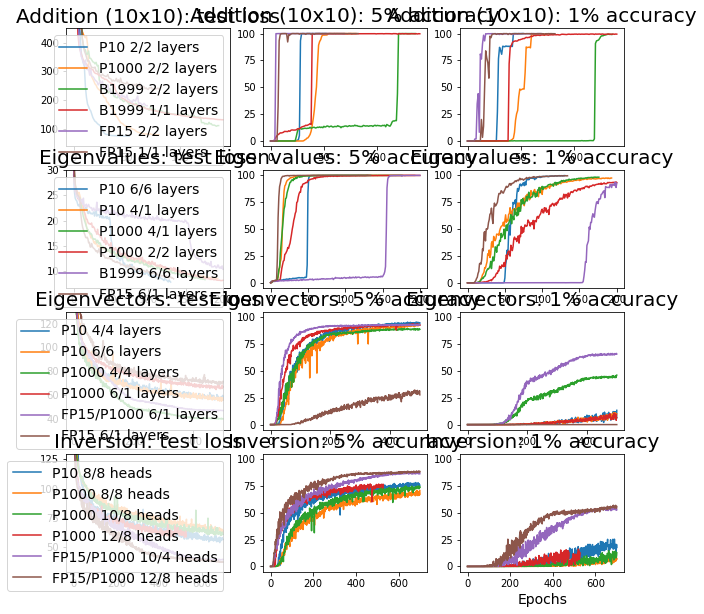

In [195]:
import os
import matplotlib.pyplot as plt
from IPython.core.display import HTML

display(HTML("<style>.container {width:90% !important;}</style>"))
display(HTML("<style>pre { white-space: pre !important; }</style>"))



#titles = ['Transposition\n5-15 rectangular matrices','Addition\n10x10 matrices', 'Matrix vector multiplication\n5x5 matrices', 'Eigenvalues\n5x5 matrices', 'Eigenvalues\n5-15 matrices', 'Eigenvalues\n10x10 matrices', 'Singular Values\n4x4 matrices', 'Eigenvectors\n6x6 matrices', 'Matrix Inversion\n5x5 matrices']
#max_epoch=[None,None,25,60,None,None,300,200,400]
  
path = [
['/checkpoint/fcharton/dumped/num_add1010/44061130',
'/checkpoint/fcharton/dumped/num_add1010/44061141',
'/checkpoint/fcharton/dumped/num_add1010/44061153',
'/checkpoint/fcharton/dumped/num_add1010/44061157',
'/checkpoint/fcharton/dumped/num_add1010/44061160',
'/checkpoint/fcharton/dumped/num_add1010/44061135'],
['/checkpoint/fcharton/dumped/num_eigenvalues55/44938598',
'/checkpoint/fcharton/dumped/num_eigenvalues55/44938720',
'/checkpoint/fcharton/dumped/num_eigenvalues55/44938609',
'/checkpoint/fcharton/dumped/num_eigenvalues55/44938716',
'/checkpoint/fcharton/dumped/num_eigenvalues55/44938669',
'/checkpoint/fcharton/dumped/num_eigenvalues55/44938674'],
['/checkpoint/fcharton/dumped/num_eigenvectors55/45702306',
'/checkpoint/fcharton/dumped/num_eigenvectors55/45702292',
'/checkpoint/fcharton/dumped/num_eigenvectors55_4/46277161',
'/checkpoint/fcharton/dumped/num_eigenvectors55/45702428',
'/checkpoint/fcharton/dumped/num_eigenvectors55_4/46277244',
'/checkpoint/fcharton/dumped/num_eigenvectors55/45702297'],
['/checkpoint/fcharton/dumped/num_invert55_2/45352742',
'/checkpoint/fcharton/dumped/num_invert55_2/45352787',
'/checkpoint/fcharton/dumped/num_invert55_3/45424652',
'/checkpoint/fcharton/dumped/num_invert55_4/45495632',
'/checkpoint/fcharton/dumped/num_invert55_13/46385027',
'/checkpoint/fcharton/dumped/num_invert55_13/46385024']
]




libs=[['P10 2/2 layers','P1000 2/2 layers','B1999 2/2 layers', 'B1999 1/1 layers','FP15 2/2 layers', 'FP15 1/1 layers'],    
    ['P10 6/6 layers','P10 4/1 layers','P1000 4/1 layers','P1000 2/2 layers','B1999 6/6 layers','FP15 6/1 layers'],
    ['P10 4/4 layers','P10 6/6 layers','P1000 4/4 layers','P1000 6/1 layers','FP15/P1000 6/1 layers','FP15 6/1 layers'],
    ['P10 8/8 heads','P1000 8/8 heads','P1000 10/8 heads','P1000 12/8 heads','FP15/P1000 10/4 heads','FP15/P1000 12/8 heads'],
     
     ]

probs=["Addition (10x10)","Eigenvalues","Eigenvectors",'Inversion']
max_len=[140, 200,500,700]
top_xe=[450,30,130,130]
 
    
    
    
#fig, axs = plt.subplots(2, 2)
#axs[0, 0].plot(x, y)
#axs[0, 0].set_title('Axis [0, 0]')
#axs[0, 1].plot(x, y, 'tab:orange')
#axs[0, 1].set_title('Axis [0, 1]')
#axs[1, 0].plot(x, -y, 'tab:green')
##axs[1, 0].set_title('Axis [1, 0]')
#axs[1, 1].plot(x, -y, 'tab:red')
#axs[1, 1].set_title('Axis [1, 1]')

#for ax in axs.flat:
#    ax.set(xlabel='x-label', ylabel='y-label')

# Hide x labels and tick labels for top plots and y ticks for right plots.
#for ax in axs.flat:
#    ax.label_outer()


fig, axs = plt.subplots(4,3)

i1 = 'valid_numeric_beam_acc'
i2 = 'valid_numeric_xe_loss'
i3 = 'valid_numeric_additional_2'
i4 = 'epoch'

for i in range(4):
    for j in range(6):
        pa = path[i][j]+'/train.log'
        print(pa)
        with open(pa, 'rt') as f:
                series1 = []
                series2 = []
                series3 = []
                series4 = []
                for line in f:
                    pos = line.find('__log__:')
                    try:
                        if pos >=0:
                            dic = ast.literal_eval(line[pos+8:])
                            series1.append(dic[i1])
                            series2.append(dic[i2])
                            series3.append(dic[i3])
                            series4.append(dic[i4])
                            if not max_len[i] is None and dic[i4] == max_len[i]: 
                               break
                    except:
                        continue

                axs[i][1].plot(series4,series1,label=libs[i][j])
                axs[i][0].plot(series4,series2, label=libs[i][j])
                axs[i][2].plot(series4,series3, label=libs[i][j])
#            if not max_epoch[3*i + j] is None:
#                axs[i,j].set_xlim([-2,max_epoch[3*i + j]+2])
#            if i==1 and j==0:
#                axs[i,j].set_xlim([-2,102])
#            if i==1 and j==1:
#                axs[i,j].set_xlim([-2,62])
                
#            top_title = f'{titles[3*i+j]}'
#            axs[i,j].set_title(top_title,fontsize=20)
    axs[i][1].set_ylim([-5,105])   
    axs[i][2].set_ylim([-5,105])
    axs[i][0].set_ylim([None,top_xe[i]])
    axs[i][0].set_title(probs[i]+": test loss",fontsize=20)
    axs[i][1].set_title(probs[i]+": 5% accuracy",fontsize=20)
    axs[i][2].set_title(probs[i]+": 1% accuracy",fontsize=20)
    axs[i][0].legend(fontsize=14)

    
#for ax in axs.flat:
#    ax.label_outer()

#plt.title("Accuracy vs epoch")

plt.xlabel("Epochs",fontsize=14)
#plt.ylabel("Accuracy")
#plt.grid(True)

#axs[1].legend(fontsize=14)
#axs[2].legend(fontsize=14)

plt.rcParams['figure.figsize'] = [20, 30]

plt.savefig("LearningCurves.pdf",bbox_inches="tight")
plt.show()


#### 

/checkpoint/fcharton/dumped/num_transpose1/42971018/train.log
/checkpoint/fcharton/dumped/num_add1010/44061130/train.log
/checkpoint/fcharton/dumped/num_multvec55/44311035/train.log
/checkpoint/fcharton/dumped/num_eigenvalues55/44938596/train.log
/checkpoint/fcharton/dumped/num_eigenvalues515/45266144/train.log
/checkpoint/fcharton/dumped/num_eigenvalues912/45550152/train.log
/checkpoint/fcharton/dumped/num_singularvalues44/44997737/train.log
/checkpoint/fcharton/dumped/num_eigenvector_sc_smallsq/43969695/train.log
/checkpoint/fcharton/dumped/num_invert55_13/46385024/train.log


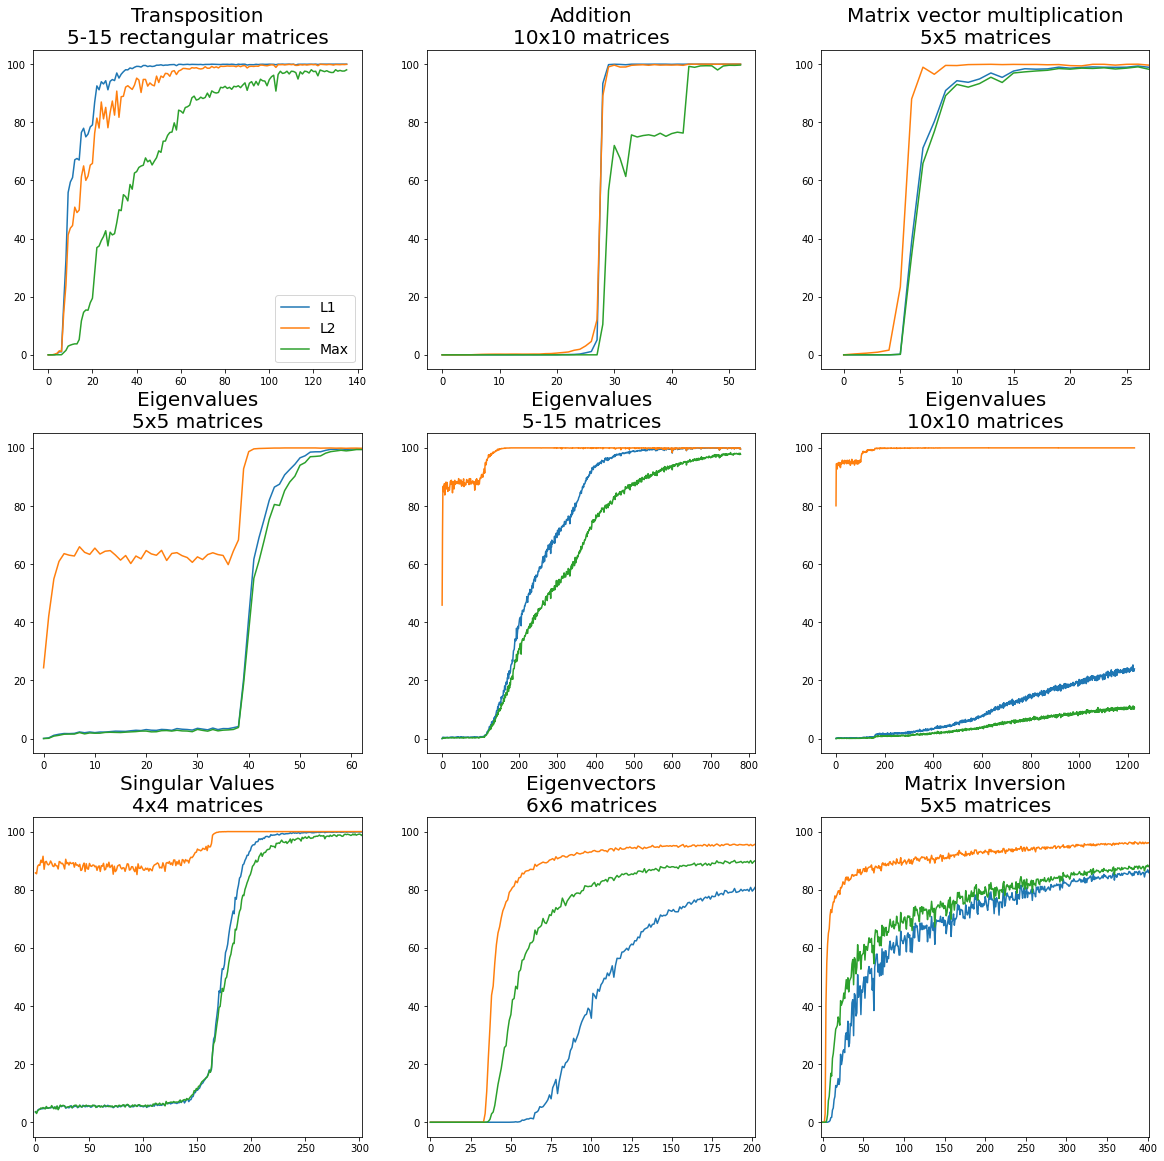

In [1745]:
import os
import matplotlib.pyplot as plt
from IPython.core.display import HTML

display(HTML("<style>.container {width:90% !important;}</style>"))
display(HTML("<style>pre { white-space: pre !important; }</style>"))


#path = [['/checkpoint/fcharton/dumped/num_eigenvalues55/449980636/','/checkpoint/fcharton/dumped/num_eigenvalues55/44938609/'],
#['/checkpoint/fcharton/dumped/num_eigenvalues88/45010687/','/checkpoint/fcharton/dumped/num_eigenvalues515/45266144/']]

titles = ['Transposition\n5-15 rectangular matrices','Addition\n10x10 matrices', 'Matrix vector multiplication\n5x5 matrices', 'Eigenvalues\n5x5 matrices', 'Eigenvalues\n5-15 matrices', 'Eigenvalues\n10x10 matrices', 'Singular Values\n4x4 matrices', 'Eigenvectors\n6x6 matrices', 'Matrix Inversion\n5x5 matrices']
max_epoch=[None,None,25,60,None,None,300,200,400]
path = [['/checkpoint/fcharton/dumped/num_transpose1/42971018','/checkpoint/fcharton/dumped/num_add1010/44061130', '/checkpoint/fcharton/dumped/num_multvec55/44311035' ],
        ['/checkpoint/fcharton/dumped/num_eigenvalues55/44938596','/checkpoint/fcharton/dumped/num_eigenvalues515/45266144','/checkpoint/fcharton/dumped/num_eigenvalues912/45550152'],
        ['/checkpoint/fcharton/dumped/num_singularvalues44/44997737','/checkpoint/fcharton/dumped/num_eigenvector_sc_smallsq/43969695','/checkpoint/fcharton/dumped/num_invert55_13/46385024']]
  
    
    
#'/checkpoint/fcharton/dumped/num_multmat55_2/44634903'
    
    
#fig, axs = plt.subplots(2, 2)
#axs[0, 0].plot(x, y)
#axs[0, 0].set_title('Axis [0, 0]')
#axs[0, 1].plot(x, y, 'tab:orange')
#axs[0, 1].set_title('Axis [0, 1]')
#axs[1, 0].plot(x, -y, 'tab:green')
##axs[1, 0].set_title('Axis [1, 0]')
#axs[1, 1].plot(x, -y, 'tab:red')
#axs[1, 1].set_title('Axis [1, 1]')

#for ax in axs.flat:
#    ax.set(xlabel='x-label', ylabel='y-label')

# Hide x labels and tick labels for top plots and y ticks for right plots.
#for ax in axs.flat:
#    ax.label_outer()


fig, axs = plt.subplots(3,3)

i1 = 'valid_numeric_beam_acc'
i2 = 'valid_numeric_beam_acc_d1'
i3 = 'valid_numeric_beam_acc_d2'
i4 = 'epoch'

for i in range(3):
    for j in range(3):
        pa = path[i][j]+'/train.log'
        print(pa)
        with open(pa, 'rt') as f:
            series1 = []
            series2 = []
            series3 = []
            series4 = []
            for line in f:
                pos = line.find('__log__:')
                try:
                    if pos >=0:
                        dic = ast.literal_eval(line[pos+8:])
                        series1.append(dic[i1])
                        series2.append(dic[i2])
                        series3.append(dic[i3])
                        series4.append(dic[i4])
                        #if dic[i4] == 600: 
                        #   break
                except:
                    continue
            axs[i,j].plot(series4,series1,label='L1')
            axs[i,j].plot(series4,series2, label='L2')
            axs[i,j].plot(series4,series3, label='Max')
            axs[i,j].set_ylim([-5,105])
            if not max_epoch[3*i + j] is None:
                axs[i,j].set_xlim([-2,max_epoch[3*i + j]+2])
#            if i==1 and j==0:
#                axs[i,j].set_xlim([-2,102])
#            if i==1 and j==1:
#                axs[i,j].set_xlim([-2,62])
                
            top_title = f'{titles[3*i+j]}'
            axs[i,j].set_title(top_title,fontsize=20)
   
    
#for ax in axs.flat:
#    ax.label_outer()

#plt.title("Accuracy vs epoch")

#plt.xlabel("Epoch")
#plt.ylabel("Accuracy")
#plt.grid(True)
axs[0,0].legend(fontsize=14)
plt.rcParams['figure.figsize'] = [20, 20]

plt.savefig("AccuracyPerNorm.pdf",bbox_inches="tight")
plt.show()


In [ ]:
def plot_attention(model):
    
    num_heads = model.n_heads
    num_layers = model.n_layers
    
    new_args = copy.deepcopy(args)
    new_args.series_length = 15
    while True:
        #try:
        tree, pred_tree, series, preds, score = predict(new_args, kwargs={'nb_ops':3, 'deg':3, 'length':10})
        break
        #except Exception as e:
            #print(e, end=' ')
    pred, true = readable_infix(pred_tree), readable_infix(tree)
    separations = [idx for idx, val in enumerate(np.array(env.input_encoder.encode(series[:len(series)//2+1]))) if val in ['+','-']]
            
    plt.figure(figsize=(4,4))
    plt.plot(series)
    plt.plot(preds, ls='--')
    plt.title(f'True: {true}\nPred: {pred}\nConfidence: {confidence:.2}', fontsize=10)
    plt.tight_layout()
    plt.savefig(savedir+'attention_plot_{}.pdf'.format(args.real_series))
        
    fig, axarr = plt.subplots(num_layers, num_heads, figsize=(2*num_heads,2*num_layers), constrained_layout=True)        
        
    for l in range(num_layers):
        module = model.attentions[l]
        scores = module.outputs.squeeze()
        
        for head in range(num_heads):                  
            axarr[l][head].matshow(scores[head])
            
            axarr[l][head].set_xticks([]) 
            axarr[l][head].set_yticks([]) 
            #for val in separations: 
            #    axarr[l][head].axvline(val, color='red', lw=.5)
            #    axarr[l][head].axhline(val, color='red', lw=.5)
                
    cols = [r'Head {}'.format(col+1) for col in range(num_heads)]
    rows = ['Layer {}'.format(row+1) for row in range(num_layers)]
    for icol, col in enumerate(cols):
        axarr[0][icol].set_title(col, fontsize=18, pad=10)
    for irow, row in enumerate(rows):
        axarr[irow][0].set_ylabel(row, fontsize=18, labelpad=10)

    plt.tight_layout()
    plt.savefig(savedir+'attention_{}.pdf'.format(args.real_series))
    plt.show()
    
    return tree, pred_tree, series, preds, score
    
tree, pred_tree, series, preds, score = plot_attention(encoder)

In [1449]:
# extract runtime errors (to do add)
for (env, xp) in xps:
    stderr_file = os.path.join(os.path.expanduser("~"), 'workdir/'+env+'/*/'+xp+'.stderr')
    found_stderr = False
    for name in glob.glob(stderr_file):
        with open(name, 'rt') as f:
            found_stderr = True
            errlines = []
            cuda = False
            for line in f:
                if line.find("RuntimeError:") >= 0:
                    errlines.append(line)
                if line.find("CUDA out of memory") >= 0:
                    cuda = True

            if len(errlines) > 0 :
                terminated[(env, xp)]=(errlines, cuda)
            else:
                runned.add((env,xp))
    if found_stderr is False:
        print("missing stderr", stderr_file)
    
print(len(terminated), "terminated with runtime errors,", len([e for (_,e) in terminated.items() if e[1] is True]), "on OOM")
print(len(runned), "run")

for name in names:
    pa = name+'/train.log'
    if not os.path.exists(pa):
        continue
    i1 = indicator+"acc"
    with open(pa, 'rt') as f:
        series1 = []
        series2 = []

        best_val = -1.0
        best_epoch = -1
        ended = False
        nanfound = False
        for line in f:
            try:
                if line.find("Stopping criterion has been below its best value for more than") >=0:
                    ended = True
                pos = line.find('__log__:')
                if pos >=0:
                    if line[pos+8:].find(': NaN,') >= 0:
                        nanfound = True
                        line = line.replace(': NaN,',': -1.0,')
                    dic = ast.literal_eval(line[pos+8:])
                    epoch = dic["epoch"]
                    val = dic[i1]
                    if val > best_val:
                        best_val = val
                        best_epoch = epoch 
                    series1.append(dic[i1])
            except:
                print("except")
                continue  
        plt.plot(series1)
    if best_val > 0:
        print(name, best_epoch, best_val, ended, epoch, val)
plt.show()


NameError: name 'runned' is not defined

In [16]:
!conda info --envs
!conda list
import tabulate


# conda environments:
#
base_env                 /private/home/fcharton/.conda/envs/base_env
base_train_env           /private/home/fcharton/.conda/envs/base_train_env
lattice_env              /private/home/fcharton/.conda/envs/lattice_env
test_sage                /private/home/fcharton/.conda/envs/test_sage
train_env_1122           /private/home/fcharton/.conda/envs/train_env_1122
train_sage               /private/home/fcharton/.conda/envs/train_sage
base                  *  /public/apps/anaconda3/2021.05

# packages in environment at /public/apps/anaconda3/2021.05:
#
# Name                    Version                   Build  Channel
_ipyw_jlab_nb_ext_conf    0.1.0                    py38_0  
_libgcc_mutex             0.1                        main  
alabaster                 0.7.12             pyhd3eb1b0_0  
anaconda                  2021.05                  py38_0  
anaconda-client           1.7.2                    py38_0  
anaconda-navigator        2.0.3                    py38_0

In [1451]:
more_tolerance = ""
[float(x) for x in more_tolerance.split(',') if len(x) > 0]

[]

In [121]:
import numpy as np
from math import log10, floor

def round_sig(x, sig=2):
    return round(x, sig-int(floor(log10(abs(x))))-1)

m = np.array([[1,2,3],[1,3,5]])
print(np.shape(m))
l, c = np.shape(m)
print(l, c)
for col in m:
    for ln in col:
        print(ln)
s = [1,2,3]
h = s[4:]
print(s,h)

rng = np.random.RandomState()
dim = rng.randint(4, 5)
matrix = np.array(2*rng.rand(dim,dim)-1)
inverse = np.linalg.inv(matrix)# + 1.0e-12 *np.eye(dim))
print("preround")
print("minmax matrix:",np.min(abs(matrix)),np.max(abs(matrix)))
print("minmax inverse:",np.min(abs(inverse)),np.max(abs(inverse)))

for i in range(dim):
    for j in range(dim):
        inverse[i,j] = round_sig(inverse[i,j],3)
        matrix[i,j] = round_sig(matrix[i,j],3)

print("postround")
print("minmax matrix:",np.min(abs(matrix)),np.max(abs(matrix)))
print("minmax inverse:",np.min(abs(inverse)),np.max(abs(inverse)))

res = abs(matrix@inverse - np.eye(dim))
print("maxresidual", np.max(res))
print("d1 residual", np.sum(res)/dim)



(2, 3)
2 3
1
2
3
1
3
5
[1, 2, 3] []
preround
minmax matrix: 0.28503928019429225 0.9907538285785604
minmax inverse: 0.5018402679225975 4.608958427951881
postround
minmax matrix: 0.285 0.991
minmax inverse: 0.502 4.61
maxresidual 0.00770599999999971
d1 residual 0.009775500000000107


In [5418]:
import numpy as np
m=5
n=6
rng = np.random.RandomState(0)
print(rng.rand(1,2))
print(rng.rand(1,2))

m1 = np.array(np.random.rand(m,n))
m2 = np.array(np.random.rand(m,n))
print(m1.shape)
print(m2.shape)
r = m1.T @ m2
print(r.shape)

[[0.5488135  0.71518937]]
[[0.60276338 0.54488318]]
(5, 6)
(5, 6)
(6, 6)


In [816]:
x= ["N1", "n2", 'N3', 'N4', 'N5', 'n6', 'N7']
x = [t if i==0 or i%3!=0 else 'T'+t[1:] for i,t in enumerate(x)]
print(x)

['N1', 'n2', 'N3', 'T4', 'N5', 'n6', 'T7']


In [142]:
import numpy as np
rng = np.random.RandomState(0)
print(rng.rand(1,2))
print(rng.rand(1,2))

rng = np.random.RandomState(0)
print(rng.rand(1,2))
print(rng.rand(1,2))

a = np.array([[1,2],[3,4]])
b = np.array([1,2])

print(np.dot(a,b))
print(np.inner(a,b))

              

[[0.5488135  0.71518937]]
[[0.60276338 0.54488318]]
[[0.5488135  0.71518937]]
[[0.60276338 0.54488318]]
[ 5 11]
[ 5 11]


In [1796]:
str = "abcd"
print(str)
print(list(str))

for i in range(5):
    print(np.random.choice(list("abcd")))
    
for i in str:
    print(i)

abcd
['a', 'b', 'c', 'd']
a
c
d
b
d
a
b
c
d


In [666]:
771476+ 477895+ 1250397+ 1250148+ 773669+ 773669+ 772486+1249909

7319649

In [585]:
w = 1
print(len(w))

TypeError: object of type 'int' has no len()